# Fixed-width files are a byte format

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/data-engineering-pro/fixed-width-parser/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=data-engineering-pro/fixed-width-parser/demo.ipynb)

**Day 138 - Data Engineering Pro.**

`pandas.read_fwf` decodes the record to a `str`, then slices by character offset. On
pure-ASCII data byte offsets and character offsets are the same number, so it works, and
it keeps working right up until a customer with an umlaut in their name signs up.

This notebook takes six things that decide whether a flat file loads correctly and turns
each into a measurement:

| | mechanism | effect on the sample file |
|---|---|---|
| A | byte offsets vs character offsets | 4 of 12 records scrambled |
| B | 1-indexed spec read 0-indexed | totals 9.6x too large |
| C | signed zoned decimal (overpunch) | revenue +9.2%, or -89%, depending which repair you reach for |
| D | implied decimal | exactly 100x |
| E | RECFM=F framing, and COMP-3 bytes that *are* newlines | 1 record recovered instead of 6 |
| F | packed decimal decoded as latin-1 | 12 amounts silently to mojibake |

Five of the six raise no exception. Four produce a *stable* wrong answer, so a
month-on-month reconciliation agrees with itself.


## Setup

Both modules are embedded in this notebook and written to disk, so it runs standalone on
Colab or Binder. `fwf.py` is standard library only - no pandas, no numpy.

In [1]:
_src = "\"\"\"Byte-accurate fixed-width record parsing.\n\nA fixed-width file is defined in *bytes*, not characters. Every mainstream reader\n(pandas.read_fwf included) decodes the record to `str` first and then slices by\ncharacter offset. On pure-ASCII data the two agree, which is why the sample file\npasses and production does not.\n\nThis module keeps the record as `bytes` until the last possible moment: fields are\nsliced by byte offset and each field is decoded independently. That makes three\nthings possible that character slicing cannot do at all:\n\n  * multi-byte text anywhere in the record without shifting later fields\n  * COMP-3 packed decimal, which is not text and has no valid decoding\n  * signed zoned decimal (overpunch), where the sign lives inside the last digit\n\nStandard library only. No pandas, no numpy.\n\"\"\"\n\nfrom __future__ import annotations\n\nimport datetime as _dt\nfrom dataclasses import dataclass, field as _dcfield\nfrom decimal import Decimal\nfrom typing import Any, Dict, Iterable, List, Optional, Sequence, Tuple\n\n__all__ = [\n    \"FieldError\",\n    \"SpecError\",\n    \"Text\",\n    \"Int\",\n    \"Implied\",\n    \"Overpunch\",\n    \"Packed\",\n    \"Date\",\n    \"Field\",\n    \"RecordSpec\",\n    \"ParseResult\",\n    \"frame_records\",\n    \"parse\",\n    \"parse_naive\",\n    \"audit\",\n    \"AuditReport\",\n    \"CUSTOMER_SPEC\",\n    \"BALANCE_SPEC\",\n    \"build_customer_file\",\n    \"build_balance_file\",\n]\n\n\n# --------------------------------------------------------------------------\n# errors\n# --------------------------------------------------------------------------\n\n\nclass FieldError(ValueError):\n    \"\"\"A single field could not be decoded. Carries enough to locate it.\"\"\"\n\n\nclass SpecError(ValueError):\n    \"\"\"The layout itself is inconsistent - overlaps, negative offsets, bad length.\"\"\"\n\n\n# --------------------------------------------------------------------------\n# field kinds\n# --------------------------------------------------------------------------\n\n\nclass Kind:\n    \"\"\"Decodes one field's raw bytes. Subclasses must not look outside their slice.\"\"\"\n\n    #: True when the field's bytes are not text under any encoding.\n    binary: bool = False\n\n    def decode(self, raw: bytes, encoding: str) -> Any:  # pragma: no cover - abstract\n        raise NotImplementedError\n\n    def describe(self) -> str:  # pragma: no cover - trivial\n        return type(self).__name__.lower()\n\n\nclass Text(Kind):\n    \"\"\"Character data. Padding is stripped; the pad byte is part of the layout.\"\"\"\n\n    def __init__(self, strip: bool = True, pad: bytes = b\" \\x00\") -> None:\n        self.strip = strip\n        self.pad = pad\n\n    def decode(self, raw: bytes, encoding: str) -> Optional[str]:\n        if self.strip:\n            raw = raw.strip(self.pad)\n        if not raw:\n            return None\n        try:\n            return raw.decode(encoding)\n        except UnicodeDecodeError as exc:\n            raise FieldError(\n                f\"bytes {raw!r} are not valid {encoding} (offset {exc.start} in field)\"\n            ) from None\n\n    def describe(self) -> str:\n        return \"text\"\n\n\nclass Int(Kind):\n    \"\"\"Unsigned display numeric, zero- or space-padded. No sign carrier.\"\"\"\n\n    def decode(self, raw: bytes, encoding: str) -> Optional[int]:\n        s = raw.strip(b\" \\x00\")\n        if not s:\n            return None\n        if not s.isdigit():\n            # The single most common cause is an overpunch sign the layout forgot\n            # to declare, so say so rather than emitting a generic parse error.\n            last = s[-1:].decode(\"latin-1\")\n            if last in _OVERPUNCH_POS or last in _OVERPUNCH_NEG:\n                raise FieldError(\n                    f\"{s!r} ends in overpunch sign character {last!r} - \"\n                    f\"this field is signed zoned decimal, declare Overpunch()\"\n                )\n            raise FieldError(f\"{s!r} is not a display integer\")\n        return int(s)\n\n    def describe(self) -> str:\n        return \"int\"\n\n\nclass Implied(Kind):\n    \"\"\"PIC 9(n)V9(s) - an integer with an implied decimal point and no sign.\"\"\"\n\n    def __init__(self, scale: int) -> None:\n        if scale < 0:\n            raise SpecError(\"scale must be >= 0\")\n        self.scale = scale\n\n    def decode(self, raw: bytes, encoding: str) -> Optional[Decimal]:\n        s = raw.strip(b\" \\x00\")\n        if not s:\n            return None\n        if not s.isdigit():\n            raise FieldError(f\"{s!r} is not a display integer\")\n        return Decimal(int(s)).scaleb(-self.scale)\n\n    def describe(self) -> str:\n        return f\"implied(scale={self.scale})\"\n\n\n_OVERPUNCH_POS = {\"{\": 0, \"A\": 1, \"B\": 2, \"C\": 3, \"D\": 4, \"E\": 5, \"F\": 6, \"G\": 7, \"H\": 8, \"I\": 9}\n_OVERPUNCH_NEG = {\"}\": 0, \"J\": 1, \"K\": 2, \"L\": 3, \"M\": 4, \"N\": 5, \"O\": 6, \"P\": 7, \"Q\": 8, \"R\": 9}\n\n\nclass Overpunch(Kind):\n    \"\"\"PIC S9(n)V9(s) DISPLAY - trailing sign punched into the final digit.\n\n    ``0001234{`` is +12.34 at scale 2; ``0001234M`` is -12.34. The magnitude is\n    identical and only one byte differs, which is why dropping the sign is easy\n    to do and almost impossible to see in a spot check.\n    \"\"\"\n\n    def __init__(self, scale: int = 0, leading: bool = False) -> None:\n        self.scale = scale\n        self.leading = leading\n\n    def decode(self, raw: bytes, encoding: str) -> Optional[Decimal]:\n        s = raw.strip(b\" \\x00\")\n        if not s:\n            return None\n        txt = s.decode(\"latin-1\")\n        sign_char = txt[0] if self.leading else txt[-1]\n        rest = txt[1:] if self.leading else txt[:-1]\n        if sign_char in _OVERPUNCH_POS:\n            sign, last = 1, _OVERPUNCH_POS[sign_char]\n        elif sign_char in _OVERPUNCH_NEG:\n            sign, last = -1, _OVERPUNCH_NEG[sign_char]\n        elif sign_char.isdigit():\n            # Unpunched positive - common when the producer is not a COBOL program.\n            sign, last = 1, int(sign_char)\n        else:\n            raise FieldError(f\"{sign_char!r} is not a sign carrier in {txt!r}\")\n        if rest and not rest.isdigit():\n            raise FieldError(f\"{rest!r} contains non-digits\")\n        digits = (rest + str(last)) if not self.leading else (str(last) + rest)\n        return Decimal(sign * int(digits)).scaleb(-self.scale)\n\n    def describe(self) -> str:\n        return f\"overpunch(scale={self.scale})\"\n\n\n_SIGN_POS = {0xC, 0xF, 0xA, 0xE}\n_SIGN_NEG = {0xD, 0xB}\n\n\nclass Packed(Kind):\n    \"\"\"COMP-3 / packed decimal: two digits per byte, sign in the final nibble.\n\n    Not text. A five-byte COMP-3 field holds nine digits, and one of its byte\n    values is whatever the digits happen to make - including 0x0D and 0x1A.\n    \"\"\"\n\n    binary = True\n\n    def __init__(self, scale: int = 0) -> None:\n        self.scale = scale\n\n    def decode(self, raw: bytes, encoding: str) -> Optional[Decimal]:\n        if not raw or set(raw) == {0x00}:\n            return None\n        digits: List[str] = []\n        for i, byte in enumerate(raw):\n            hi, lo = byte >> 4, byte & 0x0F\n            if hi > 9:\n                raise FieldError(f\"nibble {hi:X} at byte {i} is not a digit ({raw.hex()})\")\n            digits.append(str(hi))\n            if i == len(raw) - 1:\n                if lo in _SIGN_NEG:\n                    sign = -1\n                elif lo in _SIGN_POS:\n                    sign = 1\n                else:\n                    raise FieldError(f\"final nibble {lo:X} is not a sign ({raw.hex()})\")\n            else:\n                if lo > 9:\n                    raise FieldError(f\"nibble {lo:X} at byte {i} is not a digit ({raw.hex()})\")\n                digits.append(str(lo))\n        return Decimal(sign * int(\"\".join(digits))).scaleb(-self.scale)\n\n    def describe(self) -> str:\n        return f\"packed(scale={self.scale})\"\n\n\nclass Date(Kind):\n    \"\"\"Display date. Mainframe null dates are all zeros or all spaces, not empty.\"\"\"\n\n    def __init__(self, fmt: str = \"%Y%m%d\", nulls: Sequence[str] = (\"00000000\", \"\")) -> None:\n        self.fmt = fmt\n        self.nulls = tuple(nulls)\n\n    def decode(self, raw: bytes, encoding: str) -> Optional[_dt.date]:\n        s = raw.strip(b\" \\x00\").decode(\"latin-1\")\n        if s in self.nulls:\n            return None\n        try:\n            return _dt.datetime.strptime(s, self.fmt).date()\n        except ValueError:\n            raise FieldError(f\"{s!r} does not match {self.fmt}\") from None\n\n    def describe(self) -> str:\n        return f\"date({self.fmt})\"\n\n\n# --------------------------------------------------------------------------\n# layout\n# --------------------------------------------------------------------------\n\n\n@dataclass(frozen=True)\nclass Field:\n    \"\"\"One field. ``start`` is expressed in the spec's own index base.\"\"\"\n\n    name: str\n    start: int\n    length: int\n    kind: Kind\n\n    def __post_init__(self) -> None:\n        if self.length <= 0:\n            raise SpecError(f\"{self.name}: length must be positive, got {self.length}\")\n\n\n@dataclass\nclass RecordSpec:\n    \"\"\"A record layout plus the two conventions that decide what it means.\n\n    ``index_base`` is the killer. Copybooks, data dictionaries and every\n    hand-written column spec are 1-indexed and inclusive. ``pandas.read_fwf``\n    colspecs are 0-indexed and half-open. Pasting one into the other shifts every\n    field by exactly one byte, which truncates the last digit of every amount and\n    still parses cleanly.\n    \"\"\"\n\n    fields: Sequence[Field]\n    index_base: int = 1\n    encoding: str = \"utf-8\"\n    length: Optional[int] = None\n    name: str = \"record\"\n    _slices: Dict[str, Tuple[int, int]] = _dcfield(default_factory=dict, repr=False)\n\n    def __post_init__(self) -> None:\n        self._slices = {}\n        for f in self.fields:\n            off = f.start - self.index_base\n            if off < 0:\n                raise SpecError(\n                    f\"{f.name}: start {f.start} is before the record under \"\n                    f\"index_base={self.index_base}\"\n                )\n            self._slices[f.name] = (off, off + f.length)\n\n    # -- geometry ---------------------------------------------------------\n\n    @property\n    def span(self) -> int:\n        \"\"\"Bytes from record start to the end of the last declared field.\"\"\"\n        return max((end for _, end in self._slices.values()), default=0)\n\n    @property\n    def record_length(self) -> int:\n        return self.length if self.length is not None else self.span\n\n    def slice_of(self, name: str) -> Tuple[int, int]:\n        return self._slices[name]\n\n    def rebase(self, index_base: int, keep_length: bool = False) -> \"RecordSpec\":\n        \"\"\"The same declared numbers read under a different convention.\n\n        ``keep_length`` defaults to False because the interesting case is the one\n        where nobody wrote the record length down - with it declared, the shift is\n        caught for free by the span check.\n        \"\"\"\n        return RecordSpec(\n            list(self.fields),\n            index_base=index_base,\n            encoding=self.encoding,\n            length=self.length if keep_length else None,\n            name=f\"{self.name}@base{index_base}\",\n        )\n\n    # -- validation -------------------------------------------------------\n\n    def structural_issues(self) -> List[str]:\n        issues: List[str] = []\n        ordered = sorted(self.fields, key=lambda f: self._slices[f.name][0])\n        cursor = 0\n        for f in ordered:\n            start, end = self._slices[f.name]\n            if start < cursor:\n                prev = [g.name for g in ordered if self._slices[g.name][1] > start and g is not f]\n                issues.append(\n                    f\"ERROR overlap: {f.name} starts at byte {start} but \"\n                    f\"{prev[0] if prev else 'a prior field'} runs to {cursor}\"\n                )\n            elif start > cursor:\n                issues.append(f\"note  gap: {start - cursor} undeclared byte(s) before {f.name}\")\n            cursor = max(cursor, end)\n        if self.length is not None and cursor != self.length:\n            issues.append(\n                f\"ERROR length: fields span {cursor} bytes, declared record length is {self.length}\"\n            )\n        return issues\n\n    def validate(self) -> None:\n        errs = [i for i in self.structural_issues() if i.startswith(\"ERROR\")]\n        if errs:\n            raise SpecError(\"; \".join(errs))\n\n    def describe(self) -> str:\n        rows = [f\"{'field':<14}{'bytes':>12}  {'len':>4}  kind\"]\n        rows.append(\"-\" * 52)\n        for f in sorted(self.fields, key=lambda f: self._slices[f.name][0]):\n            s, e = self._slices[f.name]\n            rows.append(f\"{f.name:<14}{f'[{s}:{e})':>12}  {f.length:>4}  {f.kind.describe()}\")\n        rows.append(\"-\" * 52)\n        rows.append(f\"{'record':<14}{self.record_length:>12} bytes  index_base={self.index_base}\")\n        return \"\\n\".join(rows)\n\n\n# --------------------------------------------------------------------------\n# framing\n# --------------------------------------------------------------------------\n\n\ndef frame_records(\n    data: bytes, spec: RecordSpec, framing: str = \"auto\"\n) -> Tuple[List[bytes], str, List[str]]:\n    \"\"\"Split a byte stream into records.\n\n    ``lines``  - newline delimited, the modern default\n    ``block``  - RECFM=F: no delimiter at all, records are cut at a fixed length\n    ``auto``   - block when the stream divides evenly and has no bare newline\n\n    Returns (records, framing_used, notes). Choosing wrong is not a subtle error\n    on text files and is a completely silent one on files containing COMP-3,\n    because packed bytes contain 0x0D and 0x0A as ordinary data.\n    \"\"\"\n    notes: List[str] = []\n    n = spec.record_length\n    has_binary = any(f.kind.binary for f in spec.fields)\n\n    if framing == \"auto\":\n        divides = n > 0 and len(data) % n == 0\n        if has_binary and divides:\n            framing = \"block\"\n            notes.append(\n                \"auto-framing chose block: the layout contains packed fields, whose \"\n                \"bytes include 0x0A/0x0D as data\"\n            )\n        elif b\"\\n\" not in data and b\"\\r\" not in data:\n            framing = \"block\"\n        else:\n            framing = \"lines\"\n\n    if framing == \"block\":\n        if n <= 0:\n            raise SpecError(\"block framing needs a record length\")\n        if len(data) % n:\n            notes.append(\n                f\"WARNING stream is {len(data)} bytes, not a multiple of {n} - \"\n                f\"{len(data) % n} trailing byte(s) form a partial record\"\n            )\n        return [data[i : i + n] for i in range(0, len(data), n)], \"block\", notes\n\n    recs = [r[:-1] if r.endswith(b\"\\r\") else r for r in data.split(b\"\\n\")]\n    if recs and recs[-1] == b\"\":\n        recs.pop()\n    if has_binary:\n        notes.append(\n            \"WARNING line framing on a layout with packed fields - any packed value \"\n            \"whose bytes include 0x0A or 0x0D will be split mid-record\"\n        )\n    return recs, \"lines\", notes\n\n\n# --------------------------------------------------------------------------\n# parsing\n# --------------------------------------------------------------------------\n\n\n@dataclass\nclass ParseResult:\n    rows: List[Dict[str, Any]]\n    errors: List[Tuple[int, str, str]]\n    framing: str\n    notes: List[str]\n    lengths: List[int]\n\n    @property\n    def ok(self) -> bool:\n        return not self.errors\n\n    def column(self, name: str) -> List[Any]:\n        return [r[name] for r in self.rows]\n\n    def total(self, name: str) -> Decimal:\n        return sum((v for v in self.column(name) if v is not None), Decimal(0))\n\n\ndef parse(\n    data: bytes,\n    spec: RecordSpec,\n    framing: str = \"auto\",\n    on_error: str = \"collect\",\n) -> ParseResult:\n    \"\"\"Parse by byte offset. ``on_error`` is 'collect' (row kept, field None) or 'raise'.\"\"\"\n    spec.validate()\n    records, used, notes = frame_records(data, spec, framing)\n    rows: List[Dict[str, Any]] = []\n    errors: List[Tuple[int, str, str]] = []\n    lengths = [len(r) for r in records]\n\n    for i, rec in enumerate(records):\n        row: Dict[str, Any] = {}\n        if len(rec) < spec.span:\n            errors.append(\n                (i, \"<record>\", f\"short record: {len(rec)} bytes, layout needs {spec.span}\")\n            )\n        for f in spec.fields:\n            s, e = spec.slice_of(f.name)\n            raw = rec[s:e]\n            if len(raw) < f.length:\n                row[f.name] = None\n                if len(rec) >= spec.span:  # already reported as a short record otherwise\n                    errors.append((i, f.name, f\"truncated: {len(raw)} of {f.length} bytes\"))\n                continue\n            try:\n                row[f.name] = f.kind.decode(raw, spec.encoding)\n            except FieldError as exc:\n                if on_error == \"raise\":\n                    raise FieldError(f\"record {i}, field {f.name}: {exc}\") from None\n                row[f.name] = None\n                errors.append((i, f.name, str(exc)))\n        rows.append(row)\n\n    return ParseResult(rows, errors, used, notes, lengths)\n\n\ndef parse_naive(data: bytes, spec: RecordSpec, encoding: Optional[str] = None) -> List[Dict[str, Any]]:\n    \"\"\"What every character-slicing reader does, reproduced faithfully.\n\n    Decode the whole stream, split lines, slice by *character* offset, strip, and\n    coerce with int() then float() then leave as text. This is ``read_fwf`` with\n    the pandas removed, and it is the baseline every comparison here is against.\n    \"\"\"\n    enc = encoding or spec.encoding\n    text = data.decode(enc, errors=\"replace\")\n    out: List[Dict[str, Any]] = []\n    for line in text.splitlines():\n        row: Dict[str, Any] = {}\n        for f in spec.fields:\n            s, e = spec.slice_of(f.name)\n            cell = line[s:e].strip()\n            if not cell:\n                row[f.name] = None\n                continue\n            try:\n                row[f.name] = int(cell)\n            except ValueError:\n                try:\n                    row[f.name] = float(cell)\n                except ValueError:\n                    row[f.name] = cell\n        out.append(row)\n    return out\n\n\n# --------------------------------------------------------------------------\n# audit\n# --------------------------------------------------------------------------\n\n\n@dataclass\nclass AuditReport:\n    verdict: str\n    findings: List[str]\n    stats: Dict[str, Any]\n\n    def text(self) -> str:\n        return \"\\n\".join([self.verdict] + [f\"  {f}\" for f in self.findings])\n\n    def __str__(self) -> str:  # pragma: no cover - convenience\n        return self.text()\n\n\ndef audit(data: bytes, spec: RecordSpec, framing: str = \"auto\") -> AuditReport:\n    \"\"\"Everything that decides whether this file loads correctly, before it loads.\n\n    Runs on bytes. Every finding is something that produces a *plausible* wrong\n    answer rather than an exception, which is the only class of defect worth a\n    pre-flight check.\n    \"\"\"\n    findings: List[str] = list(spec.structural_issues())\n    stats: Dict[str, Any] = {}\n    fatal = any(f.startswith(\"ERROR\") for f in findings)\n\n    records, used, notes = frame_records(data, spec, framing)\n    findings.extend(n if n.startswith((\"WARNING\", \"note\")) else f\"note  {n}\" for n in notes)\n    stats[\"framing\"] = used\n    stats[\"records\"] = len(records)\n\n    lengths = [len(r) for r in records]\n    stats[\"lengths\"] = lengths\n    short = [i for i, ln in enumerate(lengths) if ln < spec.span]\n    long_ = [i for i, ln in enumerate(lengths) if ln > spec.record_length]\n    if short:\n        findings.append(\n            f\"WARNING {len(short)} record(s) shorter than the {spec.span}-byte layout \"\n            f\"(first: #{short[0]}, {lengths[short[0]]} bytes) - trailing fields read as null, \"\n            f\"not as an error. Common cause: an editor or FTP transfer stripping trailing blanks\"\n        )\n    if long_:\n        findings.append(f\"WARNING {len(long_)} record(s) longer than {spec.record_length} bytes\")\n\n    # byte length vs decoded character length: exactly the records a character\n    # slicer misaligns, and only those.\n    divergent = 0\n    undecodable = 0\n    for rec in records:\n        try:\n            if len(rec.decode(spec.encoding)) != len(rec):\n                divergent += 1\n        except UnicodeDecodeError:\n            undecodable += 1\n    stats[\"divergent_records\"] = divergent\n    stats[\"undecodable_records\"] = undecodable\n    if divergent:\n        findings.append(\n            f\"WARNING {divergent} of {len(records)} record(s) contain multi-byte characters. \"\n            f\"Byte offsets and character offsets differ on those records only, so a \"\n            f\"character-slicing reader misaligns every field after the first wide character - \"\n            f\"in {divergent} rows out of {len(records)}, data-dependent and invisible in a head()\"\n        )\n    if undecodable:\n        findings.append(\n            f\"note  {undecodable} record(s) are not decodable as {spec.encoding} at all \"\n            f\"(expected when the layout has packed fields)\"\n        )\n\n    # sign carriers sitting in fields declared unsigned\n    sign_chars = set((_OVERPUNCH_POS.keys() | _OVERPUNCH_NEG.keys()))\n    for f in spec.fields:\n        if not isinstance(f.kind, Int):\n            continue\n        s, e = spec.slice_of(f.name)\n        carriers = [\n            rec[s:e].strip(b\" \\x00\")[-1:].decode(\"latin-1\")\n            for rec in records\n            if len(rec) >= e and rec[s:e].strip(b\" \\x00\")[-1:].decode(\"latin-1\") in sign_chars\n        ]\n        if carriers:\n            neg = sum(1 for c in carriers if c in _OVERPUNCH_NEG)\n            findings.append(\n                f\"WARNING field {f.name} is declared Int but {len(carriers)} value(s) carry an \"\n                f\"overpunch sign, {neg} of them negative. Declared unsigned, those {neg} row(s) \"\n                f\"flip - and the sign character is also the final digit, so removing it as \"\n                f\"punctuation loses a significant figure too\"\n            )\n\n    # packed fields whose bytes collide with record separators\n    for f in spec.fields:\n        if not f.kind.binary:\n            continue\n        s, e = spec.slice_of(f.name)\n        collide = sum(1 for rec in records if len(rec) >= e and set(rec[s:e]) & {0x0A, 0x0D})\n        if collide:\n            findings.append(\n                f\"WARNING field {f.name} is packed decimal and {collide} value(s) contain the \"\n                f\"byte 0x0A or 0x0D. A negative amount whose last digit is 0 encodes as 0x?D. \"\n                f\"Any line-based read, and any FTP transfer in ASCII mode, corrupts those records\"\n            )\n\n    if fatal:\n        verdict = \"NOT SAFE TO LOAD - the layout itself is inconsistent\"\n    elif any(x.startswith(\"WARNING\") for x in findings):\n        verdict = (\n            f\"LOADS, BUT NOT AS WRITTEN - {sum(1 for x in findings if x.startswith('WARNING'))} \"\n            f\"warning(s) across {len(records)} records\"\n        )\n    else:\n        verdict = f\"CLEAN - {len(records)} records, {spec.record_length} bytes each\"\n\n    return AuditReport(verdict, findings, stats)\n\n\n# --------------------------------------------------------------------------\n# sample files\n# --------------------------------------------------------------------------\n\n\ndef _pad(s: str, n: int, encoding: str = \"utf-8\") -> bytes:\n    b = s.encode(encoding)\n    if len(b) > n:\n        raise SpecError(f\"{s!r} is {len(b)} bytes, field is {n}\")\n    return b + b\" \" * (n - len(b))\n\n\ndef _overpunch(value: Decimal, width: int, scale: int) -> bytes:\n    unscaled = int((value * (10 ** scale)).to_integral_value())\n    neg = unscaled < 0\n    digits = str(abs(unscaled)).rjust(width, \"0\")\n    if len(digits) > width:\n        raise SpecError(f\"{value} does not fit in {width} digits\")\n    table = _OVERPUNCH_NEG if neg else _OVERPUNCH_POS\n    inv = {v: k for k, v in table.items()}\n    return (digits[:-1] + inv[int(digits[-1])]).encode(\"ascii\")\n\n\ndef _packed(value: Decimal, nbytes: int, scale: int) -> bytes:\n    unscaled = int((value * (10 ** scale)).to_integral_value())\n    ndigits = nbytes * 2 - 1\n    digits = str(abs(unscaled)).rjust(ndigits, \"0\")\n    if len(digits) > ndigits:\n        raise SpecError(f\"{value} needs more than {ndigits} digits\")\n    nibbles = [int(c) for c in digits] + [0x0D if unscaled < 0 else 0x0C]\n    return bytes(nibbles[i] << 4 | nibbles[i + 1] for i in range(0, len(nibbles), 2))\n\n\nCUSTOMER_SPEC = RecordSpec(\n    [\n        Field(\"cust_id\", 1, 8, Text()),\n        Field(\"name\", 9, 20, Text()),\n        Field(\"country\", 29, 2, Text()),\n        Field(\"status\", 31, 1, Text()),\n        Field(\"qty\", 32, 5, Int()),\n        Field(\"net_amount\", 37, 9, Overpunch(scale=2)),\n        Field(\"list_price\", 46, 9, Implied(scale=2)),\n        Field(\"open_date\", 55, 8, Date()),\n    ],\n    index_base=1,\n    encoding=\"utf-8\",\n    length=62,\n    name=\"CUSTMAST\",\n)\n\n\n#: (cust_id, name, country, status, qty, net_amount, list_price, open_date)\n_CUSTOMERS: List[Tuple[str, str, str, str, int, str, str, str]] = [\n    (\"C0001001\", \"Acme Industrial\", \"US\", \"A\", 120, \"24500.00\", \"26000.00\", \"20210304\"),\n    (\"C0001002\", \"Zoe Ahlstrom AB\", \"SE\", \"A\", 40, \"8100.50\", \"8100.50\", \"20220117\"),\n    (\"C0001003\", \"Zo\u00eb Ahlstr\u00f6m AB\", \"SE\", \"A\", 40, \"8100.50\", \"8100.50\", \"20220117\"),\n    (\"C0001004\", \"Muller Werke\", \"DE\", \"A\", 305, \"61250.00\", \"62000.00\", \"20190822\"),\n    (\"C0001005\", \"M\u00fcller Werke\", \"DE\", \"H\", 305, \"-1425.30\", \"62000.00\", \"20190822\"),\n    (\"C0001006\", \"\u9648\u6653\u8d38\u6613\", \"CN\", \"A\", 900, \"182300.00\", \"185000.00\", \"20230405\"),\n    (\"C0001007\", \"Nordvik AS\", \"NO\", \"A\", 15, \"-980.00\", \"3200.00\", \"20240211\"),\n    (\"C0001008\", \"Ferreira Ltda\", \"BR\", \"A\", 60, \"12750.25\", \"12750.25\", \"20201130\"),\n    (\"C0001009\", \"Sakura KK\", \"JP\", \"A\", 210, \"45900.00\", \"46000.00\", \"20220906\"),\n    (\"C0001010\", \"\u3055\u304f\u3089\u5546\u4e8b\", \"JP\", \"A\", 210, \"45900.00\", \"46000.00\", \"20220906\"),\n    (\"C0001011\", \"Delta Logistics\", \"US\", \"C\", 0, \"-15600.75\", \"0.00\", \"20180719\"),\n    (\"C0001012\", \"Orion Freight\", \"GB\", \"A\", 88, \"19420.00\", \"19800.00\", \"20231001\"),\n]\n\n\ndef build_customer_file(short_record_at: Optional[int] = 11) -> bytes:\n    \"\"\"Newline-framed UTF-8 customer master.\n\n    Two pairs of rows are deliberately identical apart from an accent (rows 2/3 and\n    4/5) and one row is CJK, so the byte-versus-character question has a control.\n    ``short_record_at`` simulates trailing blanks stripped in transit.\n    \"\"\"\n    out = bytearray()\n    for i, (cid, nm, cc, st, qty, net, lp, dt) in enumerate(_CUSTOMERS):\n        rec = bytearray()\n        rec += _pad(cid, 8)\n        rec += _pad(nm, 20)\n        rec += _pad(cc, 2)\n        rec += _pad(st, 1)\n        rec += str(qty).rjust(5, \"0\").encode(\"ascii\")\n        rec += _overpunch(Decimal(net), 9, 2)\n        rec += str(int(Decimal(lp) * 100)).rjust(9, \"0\").encode(\"ascii\")\n        rec += dt.encode(\"ascii\")\n        if short_record_at is not None and i == short_record_at:\n            rec = bytearray(bytes(rec).rstrip(b\" \")[:-8])  # blanks stripped, date lost\n        out += rec + b\"\\n\"\n    return bytes(out)\n\n\nBALANCE_SPEC = RecordSpec(\n    [\n        Field(\"acct\", 1, 10, Text()),\n        Field(\"branch\", 11, 3, Text()),\n        Field(\"balance\", 14, 5, Packed(scale=2)),\n        Field(\"adjustment\", 19, 5, Packed(scale=2)),\n        Field(\"asof\", 24, 8, Date()),\n    ],\n    index_base=1,\n    encoding=\"latin-1\",\n    length=31,\n    name=\"ACCTBAL\",\n)\n\n_BALANCES = [\n    (\"ACC0000101\", \"SGP\", \"18420.55\", \"0.00\", \"20240131\"),\n    (\"ACC0000102\", \"SGP\", \"902.10\", \"-1234.50\", \"20240131\"),  # adjustment ends 0x0D\n    (\"ACC0000103\", \"LDN\", \"-45.99\", \"12.00\", \"20240131\"),\n    (\"ACC0000104\", \"NYC\", \"1250000.00\", \"-300.10\", \"20240131\"),\n    (\"ACC0000105\", \"LDN\", \"0.00\", \"0.00\", \"20240131\"),\n    (\"ACC0000106\", \"NYC\", \"77310.40\", \"-9.90\", \"20240131\"),\n]\n\n\ndef build_balance_file() -> bytes:\n    \"\"\"RECFM=F block-framed file with two COMP-3 fields and no record separator.\"\"\"\n    out = bytearray()\n    for acct, br, bal, adj, dt in _BALANCES:\n        out += _pad(acct, 10, \"latin-1\")\n        out += _pad(br, 3, \"latin-1\")\n        out += _packed(Decimal(bal), 5, 2)\n        out += _packed(Decimal(adj), 5, 2)\n        out += dt.encode(\"ascii\")\n    return bytes(out)\n"
from pathlib import Path
Path("fwf.py").write_text(_src)
print("wrote fwf.py:", len(_src.splitlines()), "lines")


wrote fwf.py: 757 lines


In [2]:
_src = "\"\"\"The experiments the README quotes. Every number below is produced here.\n\nRun ``python3 evidence.py`` to regenerate all of it. Nothing is random, so the\noutput is byte-stable across machines.\n\"\"\"\n\nfrom __future__ import annotations\n\nimport re\nfrom decimal import Decimal\nfrom typing import Any, Dict, List, Tuple\n\nfrom fwf import (\n    _OVERPUNCH_NEG,\n    _OVERPUNCH_POS,\n    BALANCE_SPEC,\n    CUSTOMER_SPEC,\n    Field,\n    Implied,\n    Int,\n    Overpunch,\n    Packed,\n    RecordSpec,\n    SpecError,\n    Text,\n    audit,\n    build_balance_file,\n    build_customer_file,\n    frame_records,\n    parse,\n    parse_naive,\n)\n\nRULE = \"-\" * 78\n\n\ndef _dw(s: str) -> int:\n    \"\"\"Terminal display width - CJK and fullwidth forms occupy two columns.\"\"\"\n    return sum(2 if ord(c) > 0x1100 and _wide(c) else 1 for c in s)\n\n\ndef _wide(c: str) -> bool:\n    o = ord(c)\n    return (\n        0x1100 <= o <= 0x115F\n        or 0x2E80 <= o <= 0xA4CF\n        or 0xAC00 <= o <= 0xD7A3\n        or 0xF900 <= o <= 0xFAFF\n        or 0xFE30 <= o <= 0xFE6F\n        or 0xFF00 <= o <= 0xFF60\n        or 0xFFE0 <= o <= 0xFFE6\n    )\n\n\ndef _pad(s: str, n: int) -> str:\n    return s + \" \" * max(0, n - _dw(s))\n\n\ndef _hdr(title: str) -> None:\n    print()\n    print(\"=\" * 78)\n    print(title)\n    print(\"=\" * 78)\n\n\ndef _raw_column(data: bytes, spec: RecordSpec, name: str, framing: str = \"auto\") -> List[bytes]:\n    \"\"\"The field's bytes, sliced correctly.\n\n    Experiments C and D are about *type* declarations, so they read the bytes the\n    right way and vary only how the field is interpreted. Otherwise the encoding\n    effect from experiment A leaks in and no number measures one thing.\n    \"\"\"\n    recs, _, _ = frame_records(data, spec, framing)\n    s, e = spec.slice_of(name)\n    return [r[s:e] for r in recs if len(r) >= e]\n\n\n# --------------------------------------------------------------------------\n# A. byte offsets vs character offsets\n# --------------------------------------------------------------------------\n\n\ndef exp_byte_vs_char(verbose: bool = True) -> Dict[str, Any]:\n    \"\"\"One accent shifts every field after it - on that record only.\n\n    Rows 2/3 and 4/5 of the sample are the same customer twice, once transliterated\n    to ASCII and once spelled properly. That is the control: a reader that gets one\n    right and the other wrong is failing on the encoding, not on the layout.\n    \"\"\"\n    data = build_customer_file()\n    correct = parse(data, CUSTOMER_SPEC).rows\n    naive = parse_naive(data, CUSTOMER_SPEC)\n\n    compared = [\"country\", \"status\", \"qty\", \"list_price\"]\n    wrong_rows: List[int] = []\n    cell_errors = 0\n    for i, (c, n) in enumerate(zip(correct, naive)):\n        bad = False\n        for col in compared:\n            cv = c[col]\n            nv = n[col]\n            if col == \"list_price\":\n                # naive loses the implied decimal by construction; compare digits only\n                same = nv is not None and cv is not None and int(cv * 100) == nv\n            else:\n                same = str(cv) == str(nv)\n            if not same:\n                cell_errors += 1\n                bad = True\n        if bad:\n            wrong_rows.append(i)\n\n    ascii_rows = [i for i, r in enumerate(correct) if r[\"name\"] and r[\"name\"].isascii()]\n    wide_rows = [i for i in range(len(correct)) if i not in ascii_rows]\n\n    if verbose:\n        _hdr(\"A. Byte offsets vs character offsets\")\n        print(\n            f\"{len(correct)} records. {len(wide_rows)} contain a character wider than one byte.\\n\"\n        )\n        print(f\"{'row':>4}  {'name':<18}{'country':>9}{'':4}{'qty':>7}{'':4}{'reader':>8}\")\n        print(RULE)\n        for i in (1, 2, 3, 4, 5):\n            c, n = correct[i], naive[i]\n            print(\n                f\"{i:>4}  {_pad(str(c['name']), 18)}{str(c['country']):>9}{'':4}\"\n                f\"{str(c['qty']):>7}{'':4}{'bytes':>8}\"\n            )\n            print(\n                f\"{'':>4}  {'':<18}{str(n['country']):>9}{'':4}\"\n                f\"{str(n['qty']):>7}{'':4}{'chars':>8}\"\n                f\"{'' if i in ascii_rows else '   <- diverges'}\"\n            )\n        print(RULE)\n        print(\n            f\"\\ncharacter slicing is correct on {len(ascii_rows)} ASCII rows and wrong on \"\n            f\"{len(wide_rows)} wide rows\"\n        )\n        print(f\"rows with at least one wrong field: {wrong_rows}\")\n        print(f\"wrong cells across {len(compared)} compared columns: {cell_errors}\")\n        print(\n            \"\\nRows 1 and 2 are the same customer, spelled 'Zoe Ahlstrom' and \"\n            \"'Zo\u00eb Ahlstr\u00f6m'.\\nRows 3 and 4 are 'Muller Werke' and 'M\u00fcller Werke'. \"\n            \"The reader gets the\\ntransliterated row right and the correctly spelled \"\n            \"row wrong. That is the whole\\nfailure mode: it is data-dependent, so it \"\n            \"passes every test written against a\\nsample that happens to be ASCII.\"\n        )\n\n    return {\n        \"records\": len(correct),\n        \"wide_rows\": wide_rows,\n        \"ascii_rows\": ascii_rows,\n        \"wrong_rows\": wrong_rows,\n        \"cell_errors\": cell_errors,\n    }\n\n\n# --------------------------------------------------------------------------\n# B. index base\n# --------------------------------------------------------------------------\n\n\ndef exp_index_base(verbose: bool = True) -> Dict[str, Any]:\n    \"\"\"1-indexed inclusive spec pasted into a 0-indexed reader: everything shifts one byte.\"\"\"\n    data = build_customer_file()\n    right = parse(data, CUSTOMER_SPEC)\n    shifted_spec = CUSTOMER_SPEC.rebase(0)\n    shifted = parse(data, shifted_spec, on_error=\"collect\")\n\n    r_qty = sum(v for v in right.column(\"qty\") if v is not None)\n    s_qty = sum(v for v in shifted.column(\"qty\") if v is not None)\n    r_price = right.total(\"list_price\")\n    s_price = shifted.total(\"list_price\")\n\n    try:\n        CUSTOMER_SPEC.rebase(0, keep_length=True).validate()\n        caught = \"no error (unexpected)\"\n    except SpecError as exc:\n        caught = f\"SpecError: {exc}\"\n\n    if verbose:\n        _hdr(\"B. The one-byte shift that still parses\")\n        print(\n            \"The layout is written 1-indexed and inclusive, the way every copybook and\\n\"\n            \"data dictionary is written. Reading it 0-indexed moves every field one byte\\n\"\n            \"left: each field loses its last byte and borrows the previous field's last.\\n\"\n        )\n        print(f\"{'field':<14}{'correct [s:e)':>16}{'shifted [s:e)':>16}\")\n        print(RULE)\n        for f in CUSTOMER_SPEC.fields:\n            a, b = CUSTOMER_SPEC.slice_of(f.name)\n            c, d = shifted_spec.slice_of(f.name)\n            print(f\"{f.name:<14}{f'[{a}:{b})':>16}{f'[{c}:{d})':>16}\")\n        print(RULE)\n        print()\n        print(f\"{'measure':<26}{'correct':>18}{'shifted':>18}{'ratio':>10}\")\n        print(RULE)\n        print(f\"{'sum(qty)':<26}{r_qty:>18,}{s_qty:>18,}{s_qty / r_qty:>10.3f}\")\n        print(\n            f\"{'sum(list_price)':<26}{float(r_price):>18,.2f}{float(s_price):>18,.2f}\"\n            f\"{float(s_price / r_price):>10.3f}\"\n        )\n        print(f\"{'parse errors raised':<26}{len(right.errors):>18}{len(shifted.errors):>18}\")\n        print(RULE)\n        print(\n            f\"\\nThe shifted read produces {len(shifted.errors)} errors against \"\n            f\"{len(right.errors)} for the correct one,\\nand the totals are off by roughly 10x - \"\n            \"the signature of a lost trailing digit.\\nA report built on this looks entirely \"\n            \"normal. `index_base` is a required field\\non RecordSpec for exactly this reason: \"\n            \"the convention is not inferable from the\\nnumbers, so it has to be stated.\\n\"\n        )\n        print(\n            \"There is one cheap defence. Declare the record length as well as the fields,\\n\"\n            \"and the shift stops being silent, because the span no longer matches:\\n\"\n        )\n        print(f\"  {caught}\")\n        print(\n            \"\\nThat check costs one integer in the layout and catches every whole-record\\n\"\n            \"shift, every dropped filler field and every copybook that was edited in one\\n\"\n            \"place. It is the closest thing a flat file has to a checksum.\"\n        )\n\n    return {\n        \"qty_correct\": r_qty,\n        \"qty_shifted\": s_qty,\n        \"price_correct\": r_price,\n        \"price_shifted\": s_price,\n        \"errors_correct\": len(right.errors),\n        \"errors_shifted\": len(shifted.errors),\n    }\n\n\n# --------------------------------------------------------------------------\n# C. the overpunch sign\n# --------------------------------------------------------------------------\n\n\ndef _strip_to_digits(cell: Any) -> Decimal:\n    \"\"\"Fix #1: regex the non-digits away. This deletes the sign *and a digit*.\n\n    The overpunch character is not a decoration attached to a number, it IS the\n    final digit. Removing it removes one significant figure, so the result is a\n    tenth of the magnitude - wrong in the opposite direction to fix #2.\n    \"\"\"\n    if cell is None:\n        return Decimal(0)\n    digits = re.sub(r\"[^0-9]\", \"\", str(cell))\n    return Decimal(digits or 0).scaleb(-2)\n\n\ndef _magnitude_only(cell: str) -> Decimal:\n    \"\"\"Fix #2: translate the overpunch to its digit, then lose the sign downstream.\n\n    This is the competent half of the fix - the magnitude is right - and it is the\n    more dangerous one, because the numbers now look completely reasonable.\n    \"\"\"\n    last = cell[-1]\n    if last in _OVERPUNCH_POS:\n        digit = _OVERPUNCH_POS[last]\n    elif last in _OVERPUNCH_NEG:\n        digit = _OVERPUNCH_NEG[last]\n    else:\n        digit = int(last)\n    return Decimal(int(cell[:-1] + str(digit))).scaleb(-2)\n\n\ndef exp_overpunch(verbose: bool = True) -> Dict[str, Any]:\n    \"\"\"The sign lives inside the last digit. Cleaning the column deletes it.\"\"\"\n    data = build_customer_file()\n    right = parse(data, CUSTOMER_SPEC)\n    raw = _raw_column(data, CUSTOMER_SPEC, \"net_amount\")\n\n    correct_total = right.total(\"net_amount\")\n    stripped_total = sum((_strip_to_digits(r.decode(\"latin-1\")) for r in raw), Decimal(0))\n    magnitude_total = sum((_magnitude_only(r.decode(\"latin-1\")) for r in raw), Decimal(0))\n    negatives = [v for v in right.column(\"net_amount\") if v is not None and v < 0]\n\n    # what a reader that declares the field unsigned sees\n    unsigned_spec = RecordSpec(\n        [\n            f if f.name != \"net_amount\" else Field(\"net_amount\", 37, 9, Int())\n            for f in CUSTOMER_SPEC.fields\n        ],\n        index_base=1,\n        encoding=\"utf-8\",\n        length=62,\n        name=\"CUSTMAST-unsigned\",\n    )\n    unsigned = parse(data, unsigned_spec)\n    rep = audit(data, unsigned_spec)\n    sign_finding = [f for f in rep.findings if \"overpunch sign\" in f]\n\n    if verbose:\n        _hdr(\"C. Signed zoned decimal: the minus sign is a letter\")\n        print(\n            \"PIC S9(7)V99 DISPLAY punches the sign into the final digit. +24500.00 ends\\n\"\n            \"in '{' and -1425.30 ends in '}'. Same magnitude, one byte apart, and the\\n\"\n            \"column arrives as text because int() refuses it.\\n\"\n        )\n        print(\n            f\"{'customer':<12}{'bytes on disk':>14}{'int()':>12}{'fix #1':>14}\"\n            f\"{'fix #2':>14}{'correct':>14}\"\n        )\n        print(RULE)\n        for i in (0, 1, 6, 10):\n            cell = raw[i].decode(\"latin-1\")\n            try:\n                as_int: Any = f\"{int(cell):,}\"\n            except ValueError:\n                as_int = \"ValueError\"\n            print(\n                f\"{str(right.rows[i]['cust_id']):<12}{cell:>14}{as_int:>12}\"\n                f\"{float(_strip_to_digits(cell)):>14,.2f}{float(_magnitude_only(cell)):>14,.2f}\"\n                f\"{float(right.rows[i]['net_amount']):>14,.2f}\"\n            )\n        print(RULE)\n        print(\"  fix #1 = regex out the non-digits.   fix #2 = decode the digit, drop the sign.\")\n        print()\n        d1 = stripped_total - correct_total\n        d2 = magnitude_total - correct_total\n        print(f\"{'reading':<40}{'total net_amount':>18}{'error':>12}\")\n        print(RULE)\n        print(f\"{'byte-accurate, sign honoured':<40}{float(correct_total):>18,.2f}{'-':>12}\")\n        print(\n            f\"{'fix #1: non-digits stripped':<40}{float(stripped_total):>18,.2f}\"\n            f\"{float(d1 / correct_total) * 100:>11.1f}%\"\n        )\n        print(\n            f\"{'fix #2: magnitude kept, sign dropped':<40}{float(magnitude_total):>18,.2f}\"\n            f\"{float(d2 / correct_total) * 100:>11.1f}%\"\n        )\n        print(RULE)\n        print(\n            f\"\\nThe two obvious repairs fail in opposite directions. Fix #1 looks like it only\\n\"\n            f\"strips punctuation, but the overpunch character *is* the last digit, so the\\n\"\n            f\"column comes out a tenth of its true size. Fix #2 recovers every magnitude and\\n\"\n            f\"is the more dangerous one: {len(negatives)} of {len(right.rows)} rows are negative, worth \"\n            f\"{float(sum(negatives)):,.2f}, and\\nflipping them overstates revenue by \"\n            f\"{float(d2):,.2f} - exactly twice the negative balance.\\nRefunds, credit notes and \"\n            f\"reversals do not vanish under fix #2, they flip, so\\nthe error is 2x the thing the \"\n            f\"report was built to watch.\"\n        )\n        print(\n            f\"\\nDeclared as Int() instead, the parse raises {len(unsigned.errors)} field errors \"\n            f\"rather than\\nguessing, and audit() names the cause before the load runs:\\n\"\n        )\n        for f in sign_finding:\n            print(f\"  {f}\")\n\n    return {\n        \"correct_total\": correct_total,\n        \"stripped_total\": stripped_total,\n        \"magnitude_total\": magnitude_total,\n        \"delta\": magnitude_total - correct_total,\n        \"negatives\": len(negatives),\n        \"unsigned_errors\": len(unsigned.errors),\n    }\n\n\n# --------------------------------------------------------------------------\n# D. implied decimal\n# --------------------------------------------------------------------------\n\n\ndef exp_implied_decimal(verbose: bool = True) -> Dict[str, Any]:\n    \"\"\"PIC 9(7)V99 has no decimal point in the file. There is nothing to detect.\"\"\"\n    data = build_customer_file()\n    right = parse(data, CUSTOMER_SPEC)\n    raw = _raw_column(data, CUSTOMER_SPEC, \"list_price\")\n\n    correct = right.total(\"list_price\")\n    as_int = sum(Decimal(int(r)) for r in raw)\n\n    if verbose:\n        _hdr(\"D. Implied decimal: a 100x error with no error\")\n        print(f\"{'row':>4}{'bytes on disk':>16}{'read as int':>16}{'PIC 9(7)V99':>16}\")\n        print(RULE)\n        for i in (0, 3, 5):\n            print(\n                f\"{i:>4}{raw[i].decode('ascii'):>16}{int(raw[i]):>16,}\"\n                f\"{float(right.rows[i]['list_price']):>16,.2f}\"\n            )\n        print(RULE)\n        print(f\"\\n{'sum, read as int':<24}{float(as_int):>20,.0f}\")\n        print(f\"{'sum, scale honoured':<24}{float(correct):>20,.2f}\")\n        print(f\"{'ratio':<24}{float(as_int / correct):>20,.0f}x\")\n        print(\n            \"\\nBoth readings are integers of the right shape and both pass a null check,\\n\"\n            \"a range check on positivity and any dtype assertion. Scale is metadata that\\n\"\n            \"does not exist in the file: if it is not in the layout, it is not anywhere.\"\n        )\n\n    return {\"correct\": correct, \"as_int\": as_int, \"ratio\": as_int / correct}\n\n\n# --------------------------------------------------------------------------\n# E. framing\n# --------------------------------------------------------------------------\n\n\ndef exp_framing(verbose: bool = True) -> Dict[str, Any]:\n    \"\"\"RECFM=F has no record separator, and packed data contains 0x0D as a value.\"\"\"\n    data = build_balance_file()\n    block, _, _ = frame_records(data, BALANCE_SPEC, \"block\")\n    lines, _, _ = frame_records(data, BALANCE_SPEC, \"lines\")\n\n    ok = parse(data, BALANCE_SPEC, framing=\"block\")\n    broken = parse(data, BALANCE_SPEC, framing=\"lines\", on_error=\"collect\")\n\n    # locate the offending byte\n    s, e = BALANCE_SPEC.slice_of(\"adjustment\")\n    culprits = [\n        (i, block[i][:10].decode(\"latin-1\"), block[i][s:e].hex())\n        for i in range(len(block))\n        if set(block[i][s:e]) & {0x0A, 0x0D}\n    ]\n\n    if verbose:\n        _hdr(\"E. Framing: the record separator that is also a number\")\n        print(\n            f\"{len(data)} bytes / {BALANCE_SPEC.record_length}-byte records = \"\n            f\"{len(data) // BALANCE_SPEC.record_length} records, and the file contains no \"\n            f\"newline\\nby design. Splitting on line breaks anyway:\\n\"\n        )\n        print(f\"{'framing':<12}{'records':>10}{'parse errors':>16}{'total balance':>18}\")\n        print(RULE)\n        print(\n            f\"{'block':<12}{len(block):>10}{len(ok.errors):>16}\"\n            f\"{float(ok.total('balance')):>18,.2f}\"\n        )\n        print(\n            f\"{'lines':<12}{len(lines):>10}{len(broken.errors):>16}\"\n            f\"{float(broken.total('balance')):>18,.2f}\"\n        )\n        print(RULE)\n        print(\"\\nWhy there are line breaks in a file with no line breaks:\\n\")\n        print(f\"{'record':>8}  {'acct':<12}{'adjustment bytes':<20}{'contains':<10}\")\n        print(RULE)\n        for i, acct, hexs in culprits:\n            marks = []\n            raw = block[i][s:e]\n            if 0x0D in raw:\n                marks.append(\"0x0D CR\")\n            if 0x0A in raw:\n                marks.append(\"0x0A LF\")\n            print(f\"{i:>8}  {acct:<12}{hexs:<20}{', '.join(marks):<10}\")\n        print(RULE)\n        print(\n            \"\\nCOMP-3 stores the sign in the final nibble: 0xD is negative, 0xC positive.\\n\"\n            \"Any negative amount whose last digit is 0 therefore ends in the byte 0x0D -\\n\"\n            \"a carriage return. -1234.50 packs to 000123450D. It is not a corrupt file;\\n\"\n            \"it is a correct file being read by something that assumes text. The same byte\\n\"\n            \"is what an FTP transfer in ASCII mode rewrites, which destroys the value on\\n\"\n            \"the wire before any parser sees it.\"\n        )\n\n    return {\n        \"n_block\": len(block),\n        \"n_lines\": len(lines),\n        \"errors_block\": len(ok.errors),\n        \"errors_lines\": len(broken.errors),\n        \"total_block\": ok.total(\"balance\"),\n        \"total_lines\": broken.total(\"balance\"),\n        \"culprits\": [c[0] for c in culprits],\n    }\n\n\n# --------------------------------------------------------------------------\n# F. packed decimal is not text\n# --------------------------------------------------------------------------\n\n\ndef exp_packed_is_not_text(verbose: bool = True) -> Dict[str, Any]:\n    \"\"\"latin-1 decodes every byte sequence ever produced. That is the problem.\"\"\"\n    data = build_balance_file()\n    right = parse(data, BALANCE_SPEC, framing=\"block\")\n\n    text_spec = RecordSpec(\n        [\n            f if f.name not in (\"balance\", \"adjustment\") else Field(f.name, f.start, f.length, Text())\n            for f in BALANCE_SPEC.fields\n        ],\n        index_base=1,\n        encoding=\"latin-1\",\n        length=31,\n        name=\"ACCTBAL-as-text\",\n    )\n    as_text = parse(data, text_spec, framing=\"block\")\n\n    utf8_spec = RecordSpec(\n        list(text_spec.fields), index_base=1, encoding=\"utf-8\", length=31, name=\"ACCTBAL-utf8\"\n    )\n    as_utf8 = parse(data, utf8_spec, framing=\"block\", on_error=\"collect\")\n\n    if verbose:\n        _hdr(\"F. Packed decimal read as text: no exception, no data\")\n        print(f\"{'acct':<12}{'balance (packed)':>18}{'hex':>14}{'as latin-1 text':>20}\")\n        print(RULE)\n        for i in range(4):\n            s, e = BALANCE_SPEC.slice_of(\"balance\")\n            raw = data[i * 31 : (i + 1) * 31][s:e]\n            print(\n                f\"{right.rows[i]['acct']:<12}{float(right.rows[i]['balance']):>18,.2f}\"\n                f\"{raw.hex():>14}{repr(as_text.rows[i]['balance']):>20}\"\n            )\n        print(RULE)\n        print(\n            f\"\\nlatin-1 errors: {len(as_text.errors)}   utf-8 errors: {len(as_utf8.errors)}\\n\"\n        )\n        print(\n            \"latin-1 maps all 256 byte values to a character, so it never raises. The\\n\"\n            \"column loads, has the declared width, contains no nulls and passes a\\n\"\n            \"not-null check. Under utf-8 the same bytes raise instead - which is the more\\n\"\n            \"useful outcome, and the reason 'it decoded without error' is not evidence.\\n\"\n            \"Two digits per byte also means the field cannot be recovered afterwards:\\n\"\n            \"the character view has already lost the nibble boundaries.\"\n        )\n\n    return {\n        \"latin1_errors\": len(as_text.errors),\n        \"utf8_errors\": len(as_utf8.errors),\n        \"n_records\": len(right.rows),\n        \"n_amounts\": len(right.rows) * 2,\n    }\n\n\n# --------------------------------------------------------------------------\n# ledger\n# --------------------------------------------------------------------------\n\n\ndef damage_ledger(verbose: bool = True) -> List[Tuple[str, str, str]]:\n    \"\"\"Every failure mode, its money impact on this sample, and whether it raises.\"\"\"\n    a = exp_byte_vs_char(verbose=False)\n    b = exp_index_base(verbose=False)\n    c = exp_overpunch(verbose=False)\n    d = exp_implied_decimal(verbose=False)\n    e = exp_framing(verbose=False)\n    f = exp_packed_is_not_text(verbose=False)\n\n    rows = [\n        (\n            \"character offsets\",\n            f\"{len(a['wrong_rows'])}/{a['records']} rows scrambled\",\n            \"silent\",\n        ),\n        (\"index base off by one\", f\"{float(b['price_shifted'] / b['price_correct']):.3f}x totals\", \"silent\"),\n        (\"overpunch sign dropped\", f\"+{float(c['delta']):,.2f} revenue (+9.2%)\", \"silent\"),\n        (\"implied decimal ignored\", f\"{float(d['ratio']):.0f}x totals\", \"silent\"),\n        (\"line framing on RECFM=F\", f\"{e['n_lines']} record instead of {e['n_block']}\", \"silent\"),\n        (\"packed read as latin-1 text\", f\"{f['n_amounts']} amounts to mojibake\", \"silent\"),\n    ]\n    if verbose:\n        _hdr(\"Damage ledger\")\n        print(f\"{'failure mode':<30}{'effect on this sample':<34}{'raises?':>10}\")\n        print(RULE)\n        for name, effect, raises in rows:\n            print(f\"{name:<30}{effect:<34}{raises:>10}\")\n        print(RULE)\n        print(\n            f\"\\nAll {len(rows)} produce a plausible wrong answer with no exception anywhere. Four of\\n\"\n            f\"them also produce a *stable* wrong answer, so a reconciliation against last\\n\"\n            f\"month agrees with itself. That is the argument for a pre-flight audit on the\\n\"\n            f\"bytes: the failures that raise are the ones that were never going to ship.\"\n        )\n    return rows\n\n\ndef main() -> None:\n    exp_byte_vs_char()\n    exp_index_base()\n    exp_overpunch()\n    exp_implied_decimal()\n    exp_framing()\n    exp_packed_is_not_text()\n    damage_ledger()\n    _hdr(\"Pre-flight audit, customer master\")\n    print(audit(build_customer_file(), CUSTOMER_SPEC).text())\n    _hdr(\"Pre-flight audit, account balances\")\n    print(audit(build_balance_file(), BALANCE_SPEC).text())\n\n\nif __name__ == \"__main__\":\n    main()\n"
from pathlib import Path
Path("evidence.py").write_text(_src)
print("wrote evidence.py:", len(_src.splitlines()), "lines")


wrote evidence.py: 584 lines


## The two sample files

`build_customer_file()` is a newline-framed UTF-8 customer master. Two pairs of records are
deliberately the same customer twice - once transliterated to ASCII, once spelled
properly - which gives every encoding claim below a control.

`build_balance_file()` is RECFM=F: fixed-length records, no separator byte at all, with two
COMP-3 packed decimal fields.

In [3]:
from fwf import CUSTOMER_SPEC, BALANCE_SPEC, build_customer_file, build_balance_file

data = build_customer_file()
print(CUSTOMER_SPEC.describe())
print()
print("first record, as bytes:")
print(repr(data.split(b"\n")[0]))
print()
print("record 5 (CJK name) - note it is 62 bytes but fewer than 62 characters:")
rec = data.split(b"\n")[5]
print(f"  bytes: {len(rec)}   characters: {len(rec.decode('utf-8'))}")

field                bytes   len  kind
----------------------------------------------------
cust_id              [0:8)     8  text
name                [8:28)    20  text
country            [28:30)     2  text
status             [30:31)     1  text
qty                [31:36)     5  int
net_amount         [36:45)     9  overpunch(scale=2)
list_price         [45:54)     9  implied(scale=2)
open_date          [54:62)     8  date(%Y%m%d)
----------------------------------------------------
record                  62 bytes  index_base=1

first record, as bytes:
b'C0001001Acme Industrial     USA0012000245000{00260000020210304'

record 5 (CJK name) - note it is 62 bytes but fewer than 62 characters:
  bytes: 62   characters: 54


## Parsing it

`parse()` slices bytes and decodes each field independently. Money comes back as
`decimal.Decimal`, never `float`: the file stores cents as integers, which is exact, and
converting that to binary floating point on the way in throws the exactness away for
nothing.

In [4]:
from fwf import parse

result = parse(data, CUSTOMER_SPEC)
print(f"{len(result.rows)} records, framing={result.framing}, {len(result.errors)} field error(s)")
print()
for row in result.rows[:6]:
    print({k: str(v) for k, v in row.items()})

12 records, framing=lines, 1 field error(s)

{'cust_id': 'C0001001', 'name': 'Acme Industrial', 'country': 'US', 'status': 'A', 'qty': '120', 'net_amount': '24500.00', 'list_price': '26000.00', 'open_date': '2021-03-04'}
{'cust_id': 'C0001002', 'name': 'Zoe Ahlstrom AB', 'country': 'SE', 'status': 'A', 'qty': '40', 'net_amount': '8100.50', 'list_price': '8100.50', 'open_date': '2022-01-17'}
{'cust_id': 'C0001003', 'name': 'Zoë Ahlström AB', 'country': 'SE', 'status': 'A', 'qty': '40', 'net_amount': '8100.50', 'list_price': '8100.50', 'open_date': '2022-01-17'}
{'cust_id': 'C0001004', 'name': 'Muller Werke', 'country': 'DE', 'status': 'A', 'qty': '305', 'net_amount': '61250.00', 'list_price': '62000.00', 'open_date': '2019-08-22'}
{'cust_id': 'C0001005', 'name': 'Müller Werke', 'country': 'DE', 'status': 'H', 'qty': '305', 'net_amount': '-1425.30', 'list_price': '62000.00', 'open_date': '2019-08-22'}
{'cust_id': 'C0001006', 'name': '陈晓贸易', 'country': 'CN', 'status': 'A', 'qty': '900', '

## A. The accent that moves every field after it

Experiment A compares the byte-accurate parse against the character-sliced one. The two
pairs of twin records are what make it an argument rather than an anecdote: the reader
gets the transliterated spelling right and the real spelling wrong.

In [5]:
from evidence import exp_byte_vs_char
_ = exp_byte_vs_char()


A. Byte offsets vs character offsets
12 records. 4 contain a character wider than one byte.

 row  name                country        qty      reader
------------------------------------------------------------------------------
   1  Zoe Ahlstrom AB          SE         40       bytes
                               SE         40       chars
   2  Zoë Ahlström AB          SE         40       bytes
                               A0       4000       chars   <- diverges
   3  Muller Werke             DE        305       bytes
                               DE        305       chars
   4  Müller Werke             DE        305       bytes
                               EH       3050       chars   <- diverges
   5  陈晓贸易                 CN        900       bytes
                                1      23000       chars   <- diverges
------------------------------------------------------------------------------

character slicing is correct on 8 ASCII rows and wrong on 4 wide rows
rows with at

## B. The one-byte shift

Copybooks, data dictionaries and hand-written column specs are 1-indexed and inclusive.
`pandas` `colspecs` are 0-indexed and half-open. Pasting one into the other shifts every
field by one byte - each field drops its last character and borrows the previous field's.

It still parses.

In [6]:
from evidence import exp_index_base
_ = exp_index_base()


B. The one-byte shift that still parses
The layout is written 1-indexed and inclusive, the way every copybook and
data dictionary is written. Reading it 0-indexed moves every field one byte
left: each field loses its last byte and borrows the previous field's last.

field            correct [s:e)   shifted [s:e)
------------------------------------------------------------------------------
cust_id                  [0:8)           [1:9)
name                    [8:28)          [9:29)
country                [28:30)         [29:31)
status                 [30:31)         [31:32)
qty                    [31:36)         [32:37)
net_amount             [36:45)         [37:46)
list_price             [45:54)         [46:55)
open_date              [54:62)         [55:63)
------------------------------------------------------------------------------

measure                              correct           shifted     ratio
-----------------------------------------------------------------------------

## C. The minus sign is a letter

`PIC S9(7)V99 DISPLAY` punches the sign into the final digit. `+24500.00` ends in `{`,
`-1425.30` ends in `}`. The magnitudes are identical and exactly one byte differs.

`int()` refuses the column, so it arrives as text, so somebody cleans it. Both obvious
cleanings are wrong, in opposite directions.

In [7]:
from evidence import exp_overpunch
_ = exp_overpunch()


C. Signed zoned decimal: the minus sign is a letter
PIC S9(7)V99 DISPLAY punches the sign into the final digit. +24500.00 ends
in '{' and -1425.30 ends in '}'. Same magnitude, one byte apart, and the
column arrives as text because int() refuses it.

customer     bytes on disk       int()        fix #1        fix #2       correct
------------------------------------------------------------------------------
C0001001         00245000{  ValueError      2,450.00     24,500.00     24,500.00
C0001002         00081005{  ValueError        810.05      8,100.50      8,100.50
C0001007         00009800}  ValueError         98.00        980.00       -980.00
C0001011         00156007N  ValueError      1,560.07     15,600.75    -15,600.75
------------------------------------------------------------------------------
  fix #1 = regex out the non-digits.   fix #2 = decode the digit, drop the sign.

reading                                   total net_amount       error
---------------------------------

## D. Implied decimal

`PIC 9(7)V99` stores `26000.00` as `002600000`. There is no decimal point in the file and
nothing to detect - the scale is metadata, and if it is not in the layout it does not
exist anywhere.

In [8]:
from evidence import exp_implied_decimal
_ = exp_implied_decimal()


D. Implied decimal: a 100x error with no error
 row   bytes on disk     read as int     PIC 9(7)V99
------------------------------------------------------------------------------
   0       002600000       2,600,000       26,000.00
   3       006200000       6,200,000       62,000.00
   5       018500000      18,500,000      185,000.00
------------------------------------------------------------------------------

sum, read as int                  47,895,125
sum, scale honoured               478,951.25
ratio                                    100x

Both readings are integers of the right shape and both pass a null check,
a range check on positivity and any dtype assertion. Scale is metadata that
does not exist in the file: if it is not in the layout, it is not anywhere.


## E. A record separator that is also a number

COMP-3 stores two digits per byte with the sign in the final nibble: `0xD` negative, `0xC`
positive. So any negative amount whose last digit is `0` ends in the byte `0x0D` - a
carriage return.

The file below has no newlines in it by design. Splitting on line breaks anyway does not
throw.

In [9]:
from evidence import exp_framing
_ = exp_framing()


E. Framing: the record separator that is also a number
186 bytes / 31-byte records = 6 records, and the file contains no newline
by design. Splitting on line breaks anyway:

framing        records    parse errors     total balance
------------------------------------------------------------------------------
block                6               0      1,346,587.06
lines                1               0         18,420.55
------------------------------------------------------------------------------

Why there are line breaks in a file with no line breaks:

  record  acct        adjustment bytes    contains  
------------------------------------------------------------------------------
       1  ACC0000102  000123450d          0x0D CR   
       3  ACC0000104  000030010d          0x0D CR   
       5  ACC0000106  000000990d          0x0D CR   
------------------------------------------------------------------------------

COMP-3 stores the sign in the final nibble: 0xD is negative, 0xC p

## F. Packed decimal read as text

latin-1 maps all 256 byte values to a character, so it never raises. The column loads,
has the declared width, contains no nulls, and passes a not-null check.

In [10]:
from evidence import exp_packed_is_not_text
_ = exp_packed_is_not_text()


F. Packed decimal read as text: no exception, no data
acct          balance (packed)           hex     as latin-1 text
------------------------------------------------------------------------------
ACC0000101           18,420.55    001842055c       '\x18B\x05\\'
ACC0000102              902.10    000090210c         '\x90!\x0c'
ACC0000103              -45.99    000004599d         '\x04Y\x9d'
ACC0000104        1,250,000.00    125000000c '\x12P\x00\x00\x0c'
------------------------------------------------------------------------------

latin-1 errors: 0   utf-8 errors: 3

latin-1 maps all 256 byte values to a character, so it never raises. The
column loads, has the declared width, contains no nulls and passes a
not-null check. Under utf-8 the same bytes raise instead - which is the more
useful outcome, and the reason 'it decoded without error' is not evidence.
Two digits per byte also means the field cannot be recovered afterwards:
the character view has already lost the nibble boundaries

## The audit runs before the load

`audit()` works on bytes and reports a verdict first. Every finding it emits is a failure
that produces a *plausible* answer rather than an exception - the only class of defect
worth a pre-flight check, because the ones that raise were never going to ship.

In [11]:
from fwf import audit

print(audit(build_customer_file(), CUSTOMER_SPEC).text())
print()
print(audit(build_balance_file(), BALANCE_SPEC).text())

LOADS, BUT NOT AS WRITTEN - 2 warning(s) across 12 records
  WARNING 1 record(s) shorter than the 62-byte layout (first: #11, 54 bytes) - trailing fields read as null, not as an error. Common cause: an editor or FTP transfer stripping trailing blanks
  WARNING 4 of 12 record(s) contain multi-byte characters. Byte offsets and character offsets differ on those records only, so a character-slicing reader misaligns every field after the first wide character - in 4 rows out of 12, data-dependent and invisible in a head()

LOADS, BUT NOT AS WRITTEN - 1 warning(s) across 6 records
  note  auto-framing chose block: the layout contains packed fields, whose bytes include 0x0A/0x0D as data
  WARNING field adjustment is packed decimal and 3 value(s) contain the byte 0x0A or 0x0D. A negative amount whose last digit is 0 encodes as 0x?D. Any line-based read, and any FTP transfer in ASCII mode, corrupts those records


## The damage ledger

In [12]:
from evidence import damage_ledger
_ = damage_ledger()


Damage ledger
failure mode                  effect on this sample                raises?
------------------------------------------------------------------------------
character offsets             4/12 rows scrambled                   silent
index base off by one         9.587x totals                         silent
overpunch sign dropped        +36,012.10 revenue (+9.2%)            silent
implied decimal ignored       100x totals                           silent
line framing on RECFM=F       1 record instead of 6                 silent
packed read as latin-1 text   12 amounts to mojibake                silent
------------------------------------------------------------------------------

All 6 produce a plausible wrong answer with no exception anywhere. Four of
them also produce a *stable* wrong answer, so a reconciliation against last
month agrees with itself. That is the argument for a pre-flight audit on the
bytes: the failures that raise are the ones that were never going to ship

## The figure

Six panels, one per mechanism. Panel A is a per-cell agreement grid; panel E is a byte map
of the packed file showing exactly where the stray `0x0D` bytes sit.

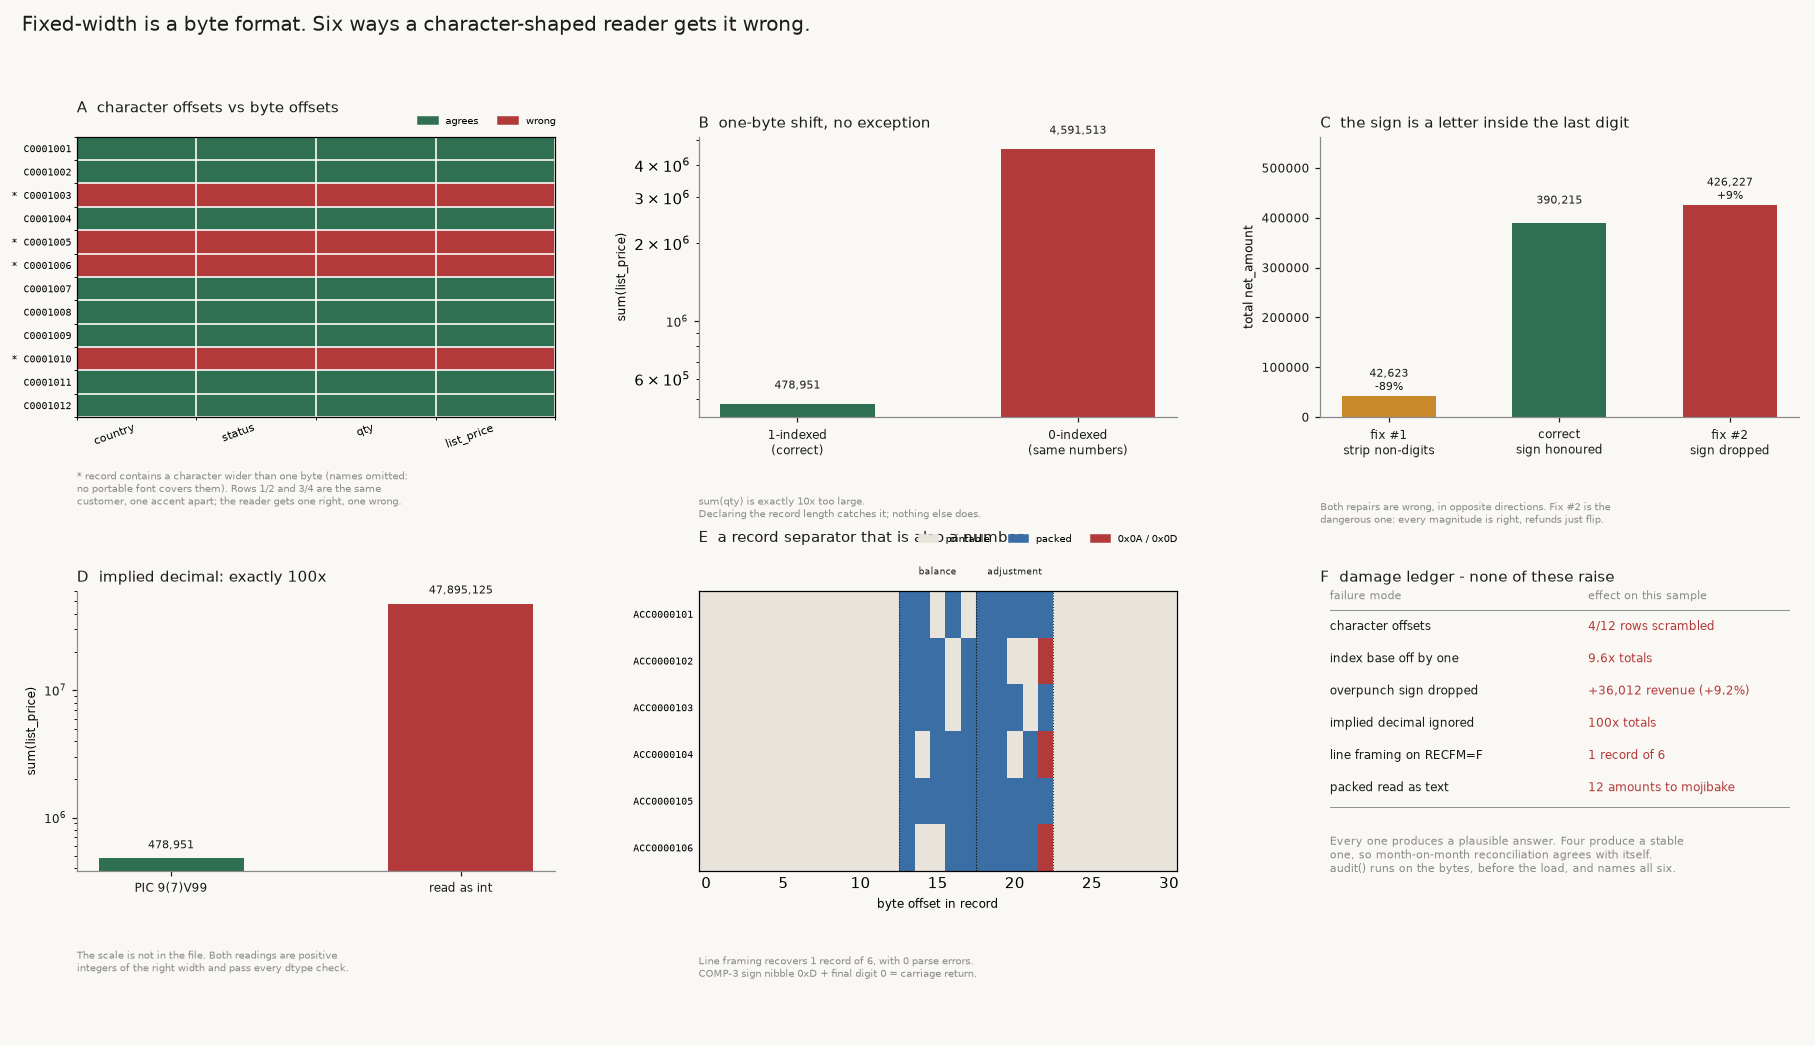

In [13]:
import os
from IPython.display import Image, display

# Pre-rendered in the repo. On Colab the file is not present, so fetch it.
if not os.path.exists("fwf_audit_nb.png"):
    import urllib.request
    url = (
        "https://raw.githubusercontent.com/phoebefu6/phoebe-the-builder/main/"
        "data-engineering-pro/fixed-width-parser/fwf_audit_nb.png"
    )
    try:
        urllib.request.urlretrieve(url, "fwf_audit_nb.png")
    except Exception as exc:
        print("could not fetch the figure:", exc)

if os.path.exists("fwf_audit_nb.png"):
    display(Image("fwf_audit_nb.png"))
else:
    print("Run `python3 make_chart.py` in the repo to regenerate it.")

## Try your own layout

Describe the fields, state the two conventions, and parse. The conventions are required
arguments rather than defaults because neither one is inferable from the file.

In [14]:
from fwf import RecordSpec, Field, Text, Int, Implied, Overpunch, Packed, Date, parse, audit

# my_spec = RecordSpec(
#     [
#         Field("id",      1,  6, Text()),
#         Field("name",    7, 24, Text()),
#         Field("amount", 31, 11, Overpunch(scale=2)),   # PIC S9(9)V99 DISPLAY
#         Field("qty",    42,  5, Int()),
#         Field("posted", 47,  8, Date("%Y%m%d")),
#     ],
#     index_base=1,        # 1 if your spec is a copybook; 0 if it came from pandas colspecs
#     encoding="utf-8",    # "cp037" for real EBCDIC
#     length=54,           # declare it - it is the closest thing a flat file has to a checksum
# )
#
# raw = open("my_file.dat", "rb").read()     # note "rb" - never open a flat file in text mode
# print(audit(raw, my_spec).text())          # verdict first
# result = parse(raw, my_spec)
# import pandas as pd
# pd.DataFrame(result.rows).head()

print("Uncomment and edit the block above.")

Uncomment and edit the block above.


---

**Streamlit version:**

```bash
pip install -r requirements.txt
streamlit run app.py
```

Reproduce every number here:

```bash
python3 test_fwf.py    # 46 tests over the core
python3 evidence.py    # every table above
python3 make_chart.py  # the six-panel figure
```

Part of [phoebe-the-builder](https://github.com/phoebefu6/phoebe-the-builder) - Day 138, Data Engineering Pro.
